# Feature Selection: SelectKBest + ANOVA (f_classif)

This notebook is a **first-pass feature selection baseline** for emotion classification.

What it does:
- loads one feature CSV
- separates metadata from model features
- trains a baseline model
- applies `SelectKBest(f_classif)`
- retrains and compares performance
- visualizes top ANOVA feature scores
- saves selected feature names and transformed datasets

**Default dataset key for this notebook:** `bert`


## 1) Imports and Notebook Settings

This cell sets up dependencies and plotting style.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

plt.style.use('ggplot')
np.random.seed(42)

print('Imports loaded.')


Imports loaded.


## 2) Configuration

Pick which extracted feature table to run.

Recommended first run: `mfcc_raw` (fast and stable).

In [3]:
REPO_ROOT = Path.cwd().resolve().parents[2] if 'feature_selection' in str(Path.cwd()) else Path.cwd().resolve()

FEATURE_SOURCES = {
    'mfcc_raw': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features.csv',
    'mfcc_normalized': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features_normalized.csv',
    'prosody_energy': REPO_ROOT / 'extracted_features' / 'prosody_energy' / 'prosody_energy_features.csv',
    'bert': REPO_ROOT / 'extracted_features' / 'text' / 'bert_embeddings.csv',
    'tfidf': REPO_ROOT / 'extracted_features' / 'text' / 'tfidf_features.csv',
    'prosody_pitch': REPO_ROOT / 'extracted_features' / 'prosody_pitch' / 'prosody_pitch_features.csv',
    'ssl_hubert': REPO_ROOT / 'extracted_features' / 'ssl_embeddings' / 'ssl_embeddings_hubert_features.csv',
    'ssl_wav2vec': REPO_ROOT / 'extracted_features' / 'ssl_embeddings' / 'ssl_embeddings_wav2vec_features.csv'
}

DATASET_KEY = 'ssl_hubert'   # change as needed
TARGET_COL = 'emotion'
TEST_SIZE = 0.20
RANDOM_STATE = 42
K_FEATURES = 300       # can be int or 'all'; actual k is clipped to available features
USE_NROWS = None           # set e.g. 5000 for quick smoke runs on huge CSVs

METADATA_CANDIDATES = {
    'path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement',
    'utt_id', 'text', 'split'
}

source_path = FEATURE_SOURCES[DATASET_KEY]
print(f'Repository root: {REPO_ROOT}')
print(f'Selected source: {source_path}')
print('Source exists:', source_path.exists())


Repository root: F:\Speech-Emotion-Recognition
Selected source: F:\Speech-Emotion-Recognition\extracted_features\ssl_embeddings\ssl_embeddings_hubert_features.csv
Source exists: True


## 3) Load Data and Identify Feature Columns

This cell infers feature columns by excluding known metadata columns.

Data shape: (9887, 1546)
Metadata columns (7): ['path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement']
Feature columns (1539).
Sample feature columns: ['duration_s', 'ssl_frames', 'ssl_dim', 'ssl_mean_0000', 'ssl_mean_0001', 'ssl_mean_0002', 'ssl_mean_0003', 'ssl_mean_0004', 'ssl_mean_0005', 'ssl_mean_0006']
Class distribution:
emotion
xxx    2507
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
Name: count, dtype: int64


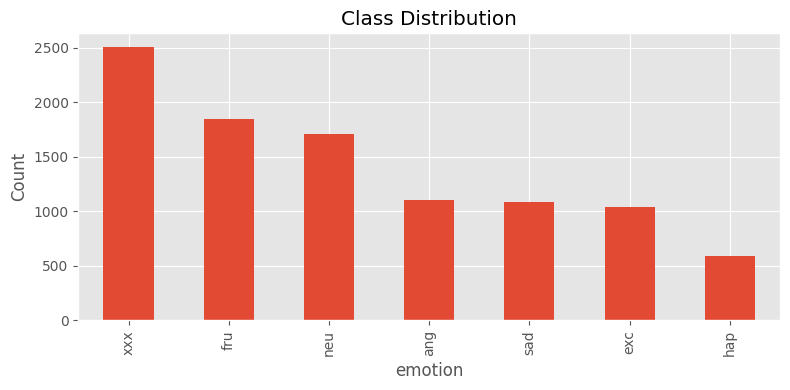

In [4]:
if not source_path.exists():
    raise FileNotFoundError(f'Missing source CSV: {source_path}')

df = pd.read_csv(source_path, nrows=USE_NROWS)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available: {list(df.columns[:20])}...")

meta_cols = [c for c in df.columns if c in METADATA_CANDIDATES]
feature_cols = [c for c in df.columns if c not in METADATA_CANDIDATES]

print(f'Data shape: {df.shape}')
print(f'Metadata columns ({len(meta_cols)}): {meta_cols}')
print(f'Feature columns ({len(feature_cols)}).')
print('Sample feature columns:', feature_cols[:10])

# quick class balance view
class_counts = df[TARGET_COL].value_counts(dropna=False)
print('Class distribution:')
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution')
ax.set_xlabel(TARGET_COL)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4) Basic Cleaning and Train/Test Split

Rows with missing labels or missing feature values are removed.

In [5]:
model_df = df[[TARGET_COL] + feature_cols].copy()

rows_before = len(model_df)
model_df = model_df.dropna(subset=[TARGET_COL])
model_df = model_df.dropna(axis=0, how='any')
rows_after = len(model_df)

X = model_df[feature_cols].astype(float)
y_raw = model_df[TARGET_COL].astype(str)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning:  {rows_after}')
print(f'Dropped rows:         {rows_before - rows_after}')
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Classes: {list(label_enc.classes_)}')

Rows before cleaning: 9887
Rows after cleaning:  9887
Dropped rows:         0
Train shape: (7909, 1539)
Test shape:  (1978, 1539)
Classes: ['ang', 'exc', 'fru', 'hap', 'neu', 'sad', 'xxx']


## 5) Baseline Model (No Feature Selection)

A logistic regression baseline gives a reference before selection.

Baseline metrics (all models):
   stage         model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro
baseline        logreg    0.3711              0.3727           0.3711       0.3697    0.3721
baseline random_forest    0.3650              0.3770           0.3650       0.3427    0.3153
baseline    linear_svc    0.3428              0.3440           0.3428       0.3407    0.3462

[logreg] classification report (baseline):
              precision    recall  f1-score   support

         ang       0.43      0.49      0.46       221
         exc       0.37      0.39      0.38       208
         fru       0.41      0.39      0.40       370
         hap       0.19      0.29      0.23       119
         neu       0.39      0.39      0.39       342
         sad       0.43      0.49      0.46       217
         xxx       0.32      0.25      0.28       501

    accuracy                           0.37      1978
   macro avg       0.36      0.38      0.37      1978
weighted av

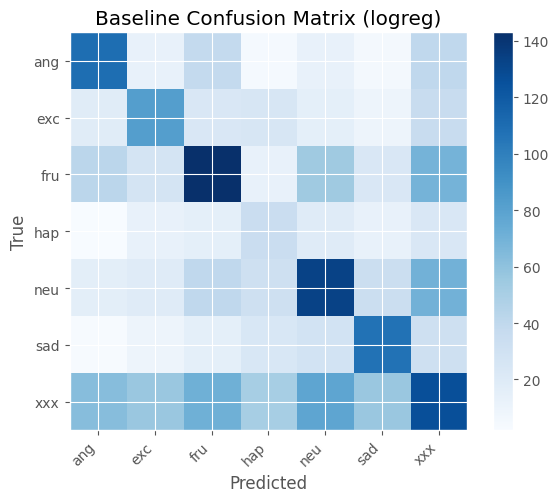

In [6]:
MODEL_SPECS = {
    'logreg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'linear_svc': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=8000)),
    ]),
    'random_forest': Pipeline([
        ('scaler', 'passthrough'),
        ('clf', RandomForestClassifier(
            n_estimators=500,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

all_labels = np.arange(len(label_enc.classes_))

def evaluate_models(X_train_eval, y_train_eval, X_test_eval, y_test_eval, stage_name: str):
    rows = []
    preds = {}

    for model_name, estimator in MODEL_SPECS.items():
        model = clone(estimator)
        model.fit(X_train_eval, y_train_eval)
        y_pred = model.predict(X_test_eval)

        preds[model_name] = y_pred
        rows.append({
            'stage': stage_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test_eval, y_pred),
            'precision': precision_score(y_test_eval, y_pred, average='weighted', zero_division=0),
            'recall': recall_score(y_test_eval, y_pred, average='weighted', zero_division=0),
            'f1': f1_score(y_test_eval, y_pred, average='weighted'),
                    })

    metrics_df = pd.DataFrame(rows).sort_values('f1', ascending=False, ignore_index=True)
    return metrics_df, preds


def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(len(label_enc.classes_)))
    ax.set_yticks(range(len(label_enc.classes_)))
    ax.set_xticklabels(label_enc.classes_, rotation=45, ha='right')
    ax.set_yticklabels(label_enc.classes_)
    plt.tight_layout()
    plt.show()


baseline_results, baseline_preds = evaluate_models(X_train, y_train, X_test, y_test, stage_name='baseline')

print('Baseline metrics (all models):')
print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in baseline_results['model']:
    print(f'\n[{model_name}] classification report (baseline):')
    print(classification_report(
        y_test,
        baseline_preds[model_name],
        labels=all_labels,
        target_names=label_enc.classes_,
        zero_division=0,
    ))

best_baseline_model = baseline_results.loc[0, 'model']
plot_confusion(y_test, baseline_preds[best_baseline_model], f'Baseline Confusion Matrix ({best_baseline_model})')

base_acc = float(baseline_results.loc[0, 'accuracy'])
base_f1 = float(baseline_results.loc[0, 'f1'])


## 6) SelectKBest (ANOVA F-test)

`f_classif` ranks each feature independently by class separability.

Original feature count: 1539
Selected feature count: 300
First 15 selected features:
 - ssl_mean_0003
 - ssl_mean_0016
 - ssl_mean_0017
 - ssl_mean_0018
 - ssl_mean_0020
 - ssl_mean_0022
 - ssl_mean_0024
 - ssl_mean_0027
 - ssl_mean_0029
 - ssl_mean_0031
 - ssl_mean_0033
 - ssl_mean_0035
 - ssl_mean_0036
 - ssl_mean_0038
 - ssl_mean_0041
Top 10 ANOVA-ranked features:
         feature  anova_f_score
0  ssl_mean_0500     279.944467
1  ssl_mean_0542     199.550812
2   ssl_std_0001     194.819098
3  ssl_mean_0672     187.887763
4  ssl_mean_0529     172.648323
5  ssl_mean_0630     171.961597
6  ssl_mean_0181     171.287681
7  ssl_mean_0213     166.914985
8  ssl_mean_0638     162.380432
9  ssl_mean_0761     131.131871


f:\Speech-Emotion-Recognition\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
f:\Speech-Emotion-Recognition\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


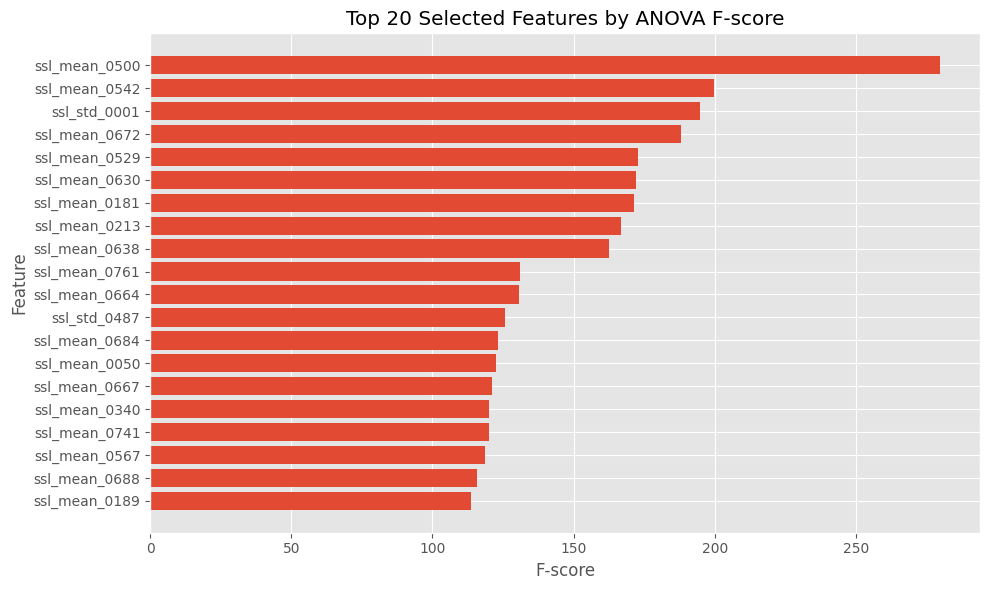

In [7]:
if K_FEATURES == 'all':
    k = 'all'
else:
    k = min(int(K_FEATURES), X_train.shape[1])

selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)

mask = selector.get_support()
selected_features = [col for col, keep in zip(feature_cols, mask) if keep]
selected_scores = selector.scores_[mask]

print(f'Original feature count: {X_train.shape[1]}')
print(f'Selected feature count: {len(selected_features)}')
print('First 15 selected features:')
for name in selected_features[:15]:
    print(' -', name)

# Top ANOVA scores
rank_df = pd.DataFrame({
    'feature': selected_features,
    'anova_f_score': selected_scores,
}).sort_values('anova_f_score', ascending=False, ignore_index=True)

print('Top 10 ANOVA-ranked features:')
print(rank_df.head(10))

plot_n = min(20, len(rank_df))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rank_df.head(plot_n)['feature'][::-1], rank_df.head(plot_n)['anova_f_score'][::-1])
ax.set_title(f'Top {plot_n} Selected Features by ANOVA F-score')
ax.set_xlabel('F-score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 7) Model After Selection

Train the same classifier, now only on selected features.

Post-selection metrics (all models):
   stage         model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro
selected    linear_svc    0.3610              0.3614           0.3610       0.3443    0.3542
selected        logreg    0.3544              0.3620           0.3544       0.3429    0.3534
selected random_forest    0.3574              0.3672           0.3574       0.3333    0.3051

[linear_svc] classification report (post-selection):
              precision    recall  f1-score   support

         ang       0.38      0.57      0.46       221
         exc       0.34      0.46      0.39       208
         fru       0.39      0.30      0.34       370
         hap       0.14      0.20      0.17       119
         neu       0.38      0.37      0.38       342
         sad       0.43      0.69      0.53       217
         xxx       0.35      0.16      0.22       501

    accuracy                           0.36      1978
   macro avg       0.34      0.39      0.35      

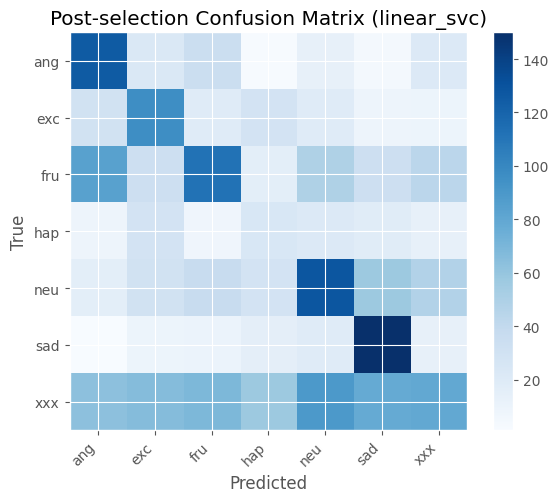


Metric delta by model (selected - baseline):
        model  accuracy_baseline  precision_weighted_baseline  recall_weighted_baseline  f1_weighted_baseline  f1_macro_baseline  accuracy_selected  precision_weighted_selected  recall_weighted_selected  f1_weighted_selected  f1_macro_selected  accuracy_delta  precision_weighted_delta  recall_weighted_delta  f1_weighted_delta  f1_macro_delta
   linear_svc             0.3428                       0.3440                    0.3428                0.3407             0.3462             0.3610                       0.3614                    0.3610                0.3443             0.3542          0.0182                    0.0175                 0.0182             0.0036          0.0081
       logreg             0.3711                       0.3727                    0.3711                0.3697             0.3721             0.3544                       0.3620                    0.3544                0.3429             0.3534         -0.0167       

In [8]:
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

selected_results, selected_preds = evaluate_models(
    X_train_sel,
    y_train,
    X_test_sel,
    y_test,
    stage_name='selected',
)

print('Post-selection metrics (all models):')
print(selected_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in selected_results['model']:
    print(f'\n[{model_name}] classification report (post-selection):')
    print(classification_report(
        y_test,
        selected_preds[model_name],
        labels=all_labels,
        target_names=label_enc.classes_,
        zero_division=0,
    ))

best_selected_model = selected_results.loc[0, 'model']
plot_confusion(y_test, selected_preds[best_selected_model], f'Post-selection Confusion Matrix ({best_selected_model})')

comparison_df = baseline_results[['model', 'accuracy', 'precision', 'recall', 'f1']].merge(
    selected_results[['model', 'accuracy', 'precision', 'recall', 'f1']],
    on='model',
    suffixes=('_baseline', '_selected'),
)
comparison_df['accuracy_delta'] = comparison_df['accuracy_selected'] - comparison_df['accuracy_baseline']
comparison_df['precision_delta'] = comparison_df['precision_selected'] - comparison_df['precision_baseline']
comparison_df['recall_delta'] = comparison_df['recall_selected'] - comparison_df['recall_baseline']
comparison_df['f1_delta'] = comparison_df['f1_selected'] - comparison_df['f1_baseline']
comparison_df = comparison_df.sort_values('f1_selected', ascending=False, ignore_index=True)

print('\nMetric delta by model (selected - baseline):')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

sel_acc = float(selected_results.loc[0, 'accuracy'])
sel_f1 = float(selected_results.loc[0, 'f1'])


## 8) Save Artifacts

This exports selected feature names, scores, and transformed train/test matrices.

In [9]:
out_dir = REPO_ROOT / 'feature_selection' / 'anova' / 'select_k_best_anova' / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)

selected_feature_path = out_dir / f'{DATASET_KEY}_selected_features.json'
rank_path = out_dir / f'{DATASET_KEY}_anova_ranking.csv'
train_sel_path = out_dir / f'{DATASET_KEY}_X_train_selected.csv'
test_sel_path = out_dir / f'{DATASET_KEY}_X_test_selected.csv'
meta_path = out_dir / f'{DATASET_KEY}_run_metadata.json'

with selected_feature_path.open('w', encoding='utf-8') as f:
    json.dump(selected_features, f, indent=2)

rank_df.to_csv(rank_path, index=False)

X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
X_train_sel_df.to_csv(train_sel_path, index=False)
X_test_sel_df.to_csv(test_sel_path, index=False)

baseline_records = baseline_results.to_dict(orient='records')
selected_records = selected_results.to_dict(orient='records')
comparison_records = comparison_df.to_dict(orient='records')
for collection in (baseline_records, selected_records, comparison_records):
    for row in collection:
        for key, value in list(row.items()):
            if isinstance(value, (np.floating, float)):
                row[key] = float(value)

run_meta = {
    'dataset_key': DATASET_KEY,
    'source_path': str(source_path),
    'target_col': TARGET_COL,
    'rows_used': int(len(model_df)),
    'original_features': int(X_train.shape[1]),
    'selected_features': int(len(selected_features)),
    'k_config': K_FEATURES,
    'k_effective': len(selected_features),
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'best_baseline_model': str(baseline_results.loc[0, 'model']),
    'best_selected_model': str(selected_results.loc[0, 'model']),
    'baseline_accuracy': float(base_acc),
    'baseline_precision': float(baseline_results.loc[0, 'precision']),
    'baseline_recall': float(baseline_results.loc[0, 'recall']),
    'baseline_f1': float(base_f1),
    'selected_accuracy': float(sel_acc),
    'selected_precision': float(selected_results.loc[0, 'precision']),
    'selected_recall': float(selected_results.loc[0, 'recall']),
    'selected_f1': float(sel_f1),
    'baseline_model_metrics': baseline_records,
    'selected_model_metrics': selected_records,
    'model_metric_deltas': comparison_records,
}

with meta_path.open('w', encoding='utf-8') as f:
    json.dump(run_meta, f, indent=2)

print('Saved artifacts:')
print('-', selected_feature_path)
print('-', rank_path)
print('-', train_sel_path)
print('-', test_sel_path)
print('-', meta_path)


Saved artifacts:
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\ssl_hubert_selected_features.json
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\ssl_hubert_anova_ranking.csv
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\ssl_hubert_X_train_selected.csv
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\ssl_hubert_X_test_selected.csv
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\ssl_hubert_run_metadata.json


## 9) Notes for Next Methods

After this baseline, common next folders/methods:
- `wrapper/rfe_logreg/`
- `embedded/l1_logreg/`
- `embedded/tree_importance/`
- `dimensionality/pca/`

In [10]:
# Delta summary (selected - baseline)
if 'comparison_df' not in globals():
    raise RuntimeError('comparison_df not found. Run the training/evaluation cells first.')

delta_cols = [
    'model',
    'accuracy_baseline',
    'accuracy_selected',
    'accuracy_delta',
    'precision_baseline',
    'precision_selected',
    'precision_delta',
    'recall_baseline',
    'recall_selected',
    'recall_delta',
    'f1_baseline',
    'f1_selected',
    'f1_delta',
]

delta_table = comparison_df[delta_cols].copy().sort_values('f1_delta', ascending=False, ignore_index=True)

print('Delta table (selected - baseline):')
print(delta_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nDelta accuracy only:')
print(
    delta_table[['model', 'accuracy_baseline', 'accuracy_selected', 'accuracy_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta precision only:')
print(
    delta_table[['model', 'precision_baseline', 'precision_selected', 'precision_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta recall only:')
print(
    delta_table[['model', 'recall_baseline', 'recall_selected', 'recall_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta F1 only:')
print(
    delta_table[['model', 'f1_baseline', 'f1_selected', 'f1_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

best_gain_row = delta_table.iloc[0]
print(
    f"\nBest F1 gain: {best_gain_row['model']} | "
    f"Delta F1={best_gain_row['f1_delta']:+.4f}, "
    f"Delta Accuracy={best_gain_row['accuracy_delta']:+.4f}"
)


Delta table (selected - baseline):
        model  accuracy_baseline  accuracy_selected  accuracy_delta  precision_weighted_baseline  precision_weighted_selected  precision_weighted_delta  recall_weighted_baseline  recall_weighted_selected  recall_weighted_delta  f1_weighted_baseline  f1_weighted_selected  f1_weighted_delta  f1_macro_baseline  f1_macro_selected  f1_macro_delta
   linear_svc             0.3428             0.3610          0.0182                       0.3440                       0.3614                    0.0175                    0.3428                    0.3610                 0.0182                0.3407                0.3443             0.0036             0.3462             0.3542          0.0081
random_forest             0.3650             0.3574         -0.0076                       0.3770                       0.3672                   -0.0098                    0.3650                    0.3574                -0.0076                0.3427                0.3333       